In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

In [5]:
mall_data = pd.read_csv("/content/drive/MyDrive/Data/Mall_Customers.xls")
mall_data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## 1 Предобработка

In [37]:
mall_data.isna().sum()

,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
mall_data.duplicated().sum()

0

array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income (k$)'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

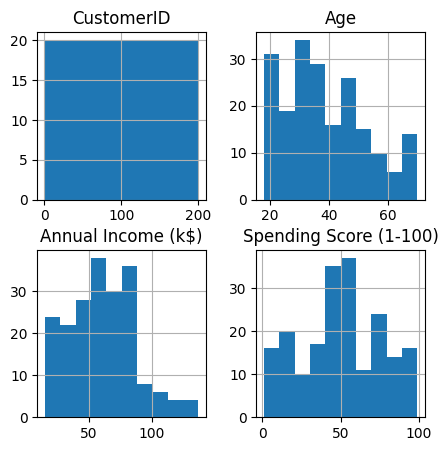

In [8]:
mall_data.hist(figsize=(5, 5))

In [ ]:
mall_data.drop(columns=["CustomerID", "Gender"], inplace=True)

Длина до удаления: 200
Длина после удаления: 198


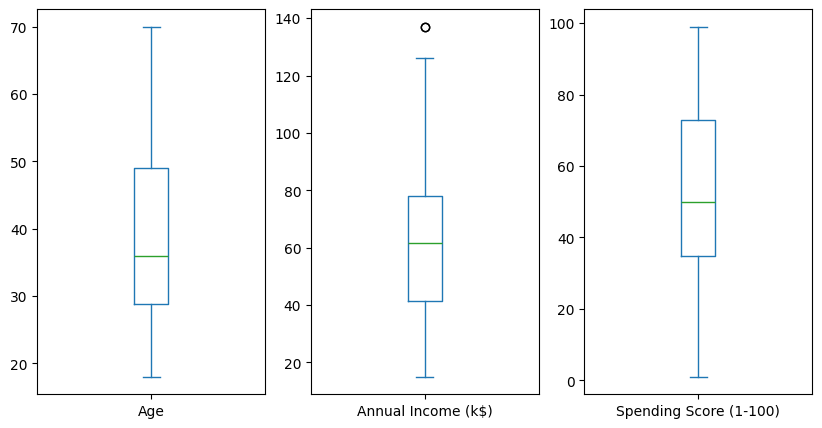

In [34]:
mall_data.plot.box(subplots=True, figsize=(10, 5))

Q1 = mall_data.quantile(0.25)
Q3 = mall_data.quantile(0.75)
IQR = Q3 - Q1
filtered_data = mall_data[(~((mall_data < (Q1 - 1.5 * IQR)) | (mall_data > (Q3 +
1.5 * IQR)))).all(axis=1)]
print(f"Длина до удаления: {len(mall_data)}")
print(f"Длина после удаления: {len(filtered_data)}")

<Axes: >

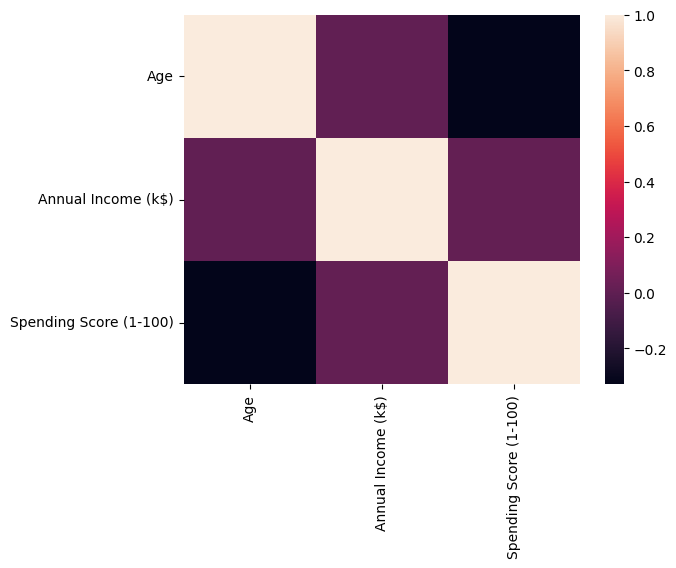

In [39]:
sns.heatmap(filtered_data.corr())

In [40]:
data = MinMaxScaler().fit_transform(filtered_data)
data

array([[0.01923077, 0.        , 0.3877551 ],
       [0.05769231, 0.        , 0.81632653],
       [0.03846154, 0.00900901, 0.05102041],
       [0.09615385, 0.00900901, 0.7755102 ],
       [0.25      , 0.01801802, 0.39795918],
       [0.07692308, 0.01801802, 0.76530612],
       [0.32692308, 0.02702703, 0.05102041],
       [0.09615385, 0.02702703, 0.94897959],
       [0.88461538, 0.03603604, 0.02040816],
       [0.23076923, 0.03603604, 0.7244898 ],
       [0.94230769, 0.03603604, 0.13265306],
       [0.32692308, 0.03603604, 1.        ],
       [0.76923077, 0.04504505, 0.14285714],
       [0.11538462, 0.04504505, 0.7755102 ],
       [0.36538462, 0.04504505, 0.12244898],
       [0.07692308, 0.04504505, 0.79591837],
       [0.32692308, 0.05405405, 0.34693878],
       [0.03846154, 0.05405405, 0.66326531],
       [0.65384615, 0.07207207, 0.28571429],
       [0.32692308, 0.07207207, 0.98979592],
       [0.32692308, 0.08108108, 0.34693878],
       [0.13461538, 0.08108108, 0.73469388],
       [0.

## 2 Реализация методов

In [13]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(data)
labels_kmeans = kmeans.labels_
centroids_kmeans = kmeans.cluster_centers_
print(labels_kmeans)

[2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 1 2 0 2 0 2 1 2 2 2 1 2 2 1 1 1 1 1 2 1 1 2 1 1 1 2 1 1 2 2 1 1 1 1
 1 2 1 1 2 1 1 2 1 1 2 1 1 2 2 1 1 2 1 4 2 2 1 2 1 2 2 1 1 2 1 2 1 1 1 1 1
 2 4 2 2 2 1 1 1 1 2 4 3 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 4 3 4 3 4 3 1 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 3 4 3 4 3 4 3]


In [41]:
agglom = AgglomerativeClustering(n_clusters=5)
agglom.fit(data)
labels_agglom = agglom.labels_
print(labels_agglom)

[4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4
 0 4 0 1 0 4 0 4 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1
 1 0 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 1
 0 1 0 0 0 1 1 1 1 0 1 1 3 0 3 1 3 2 3 2 3 0 3 2 3 2 3 2 3 2 3 0 3 2 3 1 3
 2 3 2 3 2 3 2 3 2 3 2 3 1 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3]


In [42]:
dbscan = DBSCAN(eps=0.15, min_samples=9)
dbscan.fit(data)
labels_dbscan = dbscan.labels_
print(labels_dbscan)

[-1  0 -1  0 -1  0 -1  0 -1  0 -1 -1 -1  0 -1  0 -1  0 -1 -1 -1  0 -1  0
 -1  0 -1 -1 -1  0 -1  0 -1  0 -1  0 -1  0 -1  0 -1  0  1  2  1  0  1  2
  2  2  1  2  2  1  1  1  1  1  2  1  1  2  1  1  1  2  1  1  2  2  1  1
  1  1  1  2  1  1  2  1  1  1  1  1  2  1  1  2 -1  1  1  2  1  1  2  2
  1  2  1  2  2  1  1  2  1  2  1  1  1  1  1  2  1  2  2  2  1  1  1  1
  2  1 -1  3  2  3  1  3 -1  3 -1  3  2  3 -1  3 -1  3 -1  3 -1  3 -1  3
 -1  3  1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3
 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1  3 -1 -1
 -1 -1 -1 -1 -1 -1]


## 3 Выбор оптимального кол-ва кластеров

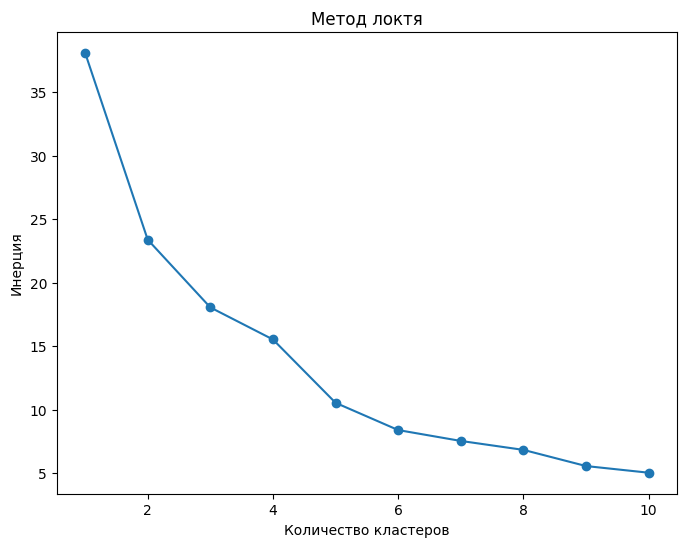

In [ ]:
# Метод локтя
inertia = []

for k in range(1, 11):
  model = KMeans(n_clusters=k)
  model.fit(data)
  inertia.append(model.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.show()

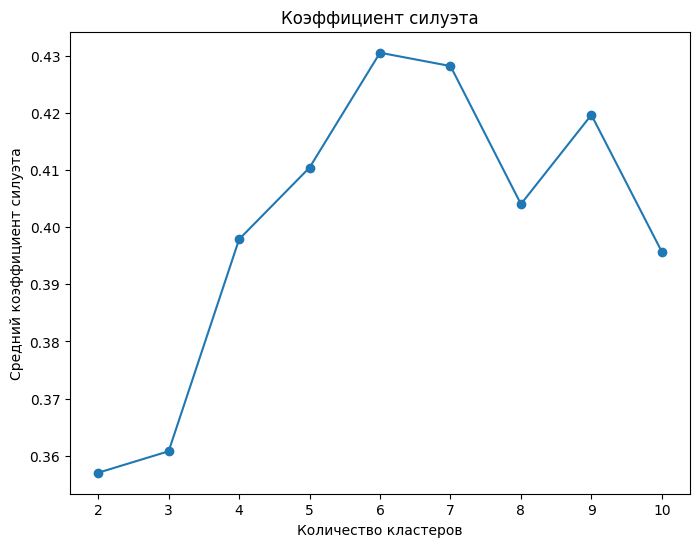

In [43]:
# Коэффициент силуэта
silhouette_scores = []

for k in range(2, 11):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(data)
  labels = kmeans.labels_
  silhouette_scores.append(silhouette_score(data, labels))

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Коэффициент силуэта')
plt.xlabel('Количество кластеров')
plt.ylabel('Средний коэффициент силуэта')
plt.show()

## 4 Строим дендограмму

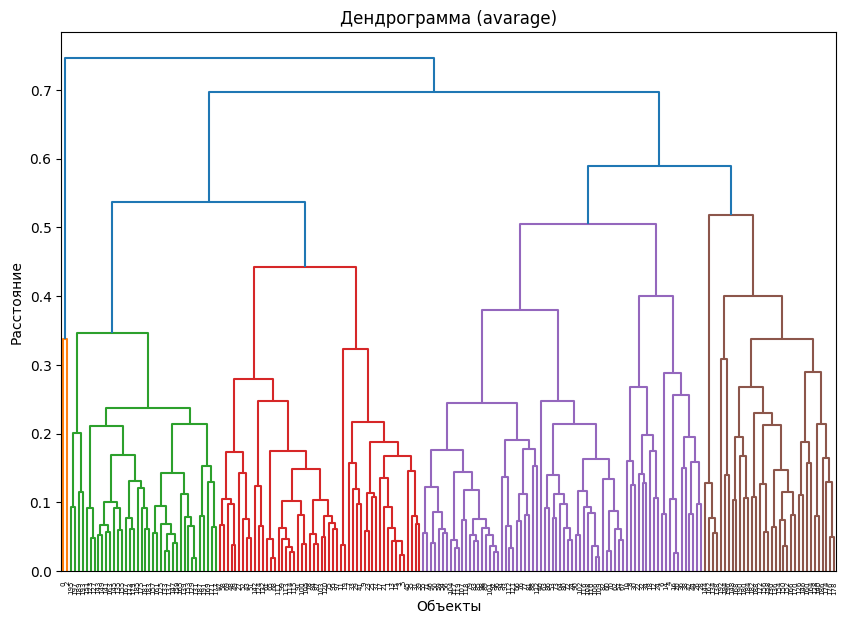

In [ ]:
Z = linkage(data, method='average')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Дендрограмма (avarage)')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

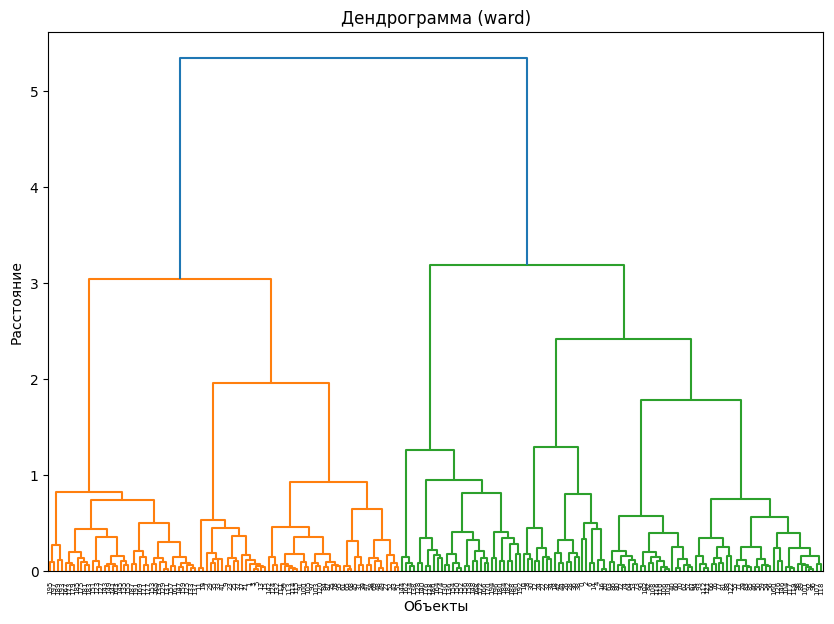

In [ ]:
Z = linkage(data, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Дендрограмма (ward)')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

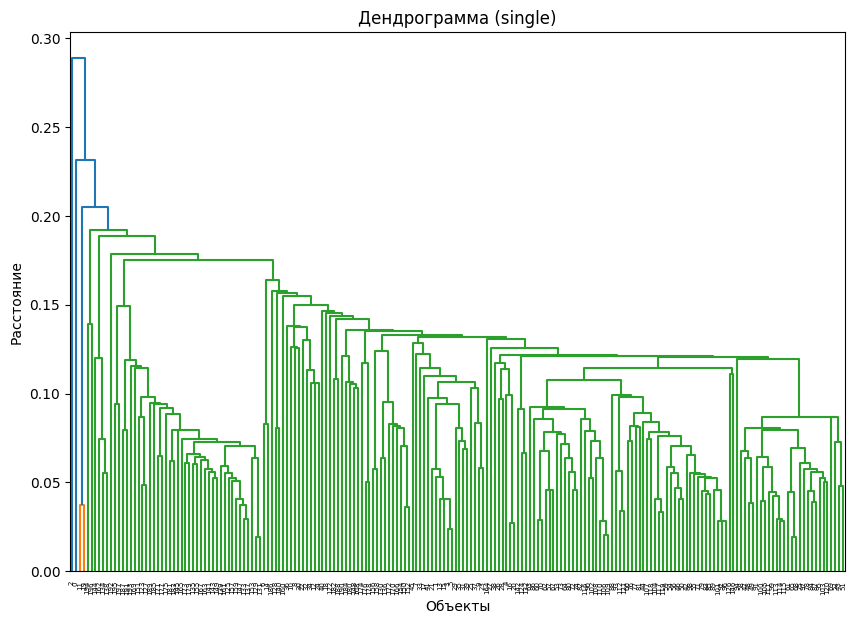

In [ ]:
Z = linkage(data, method='single')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Дендрограмма (single)')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()

## 5 Построение графиков

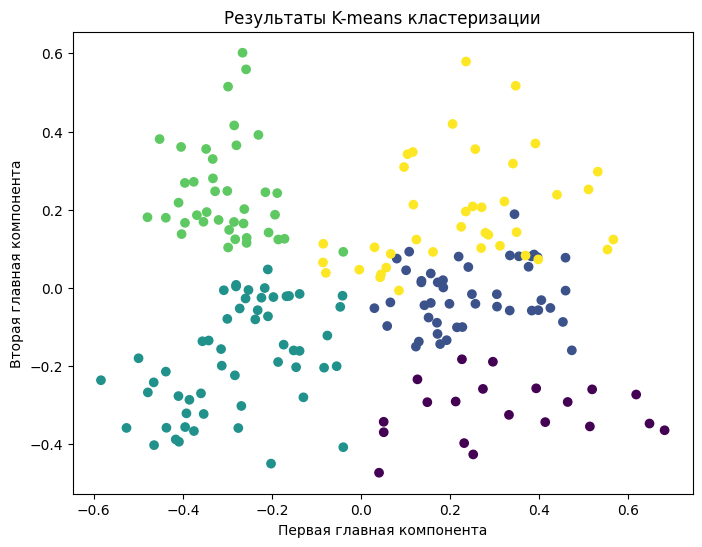

In [35]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data)
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_kmeans,
cmap='viridis', marker='o')
plt.title('Результаты K-means кластеризации')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

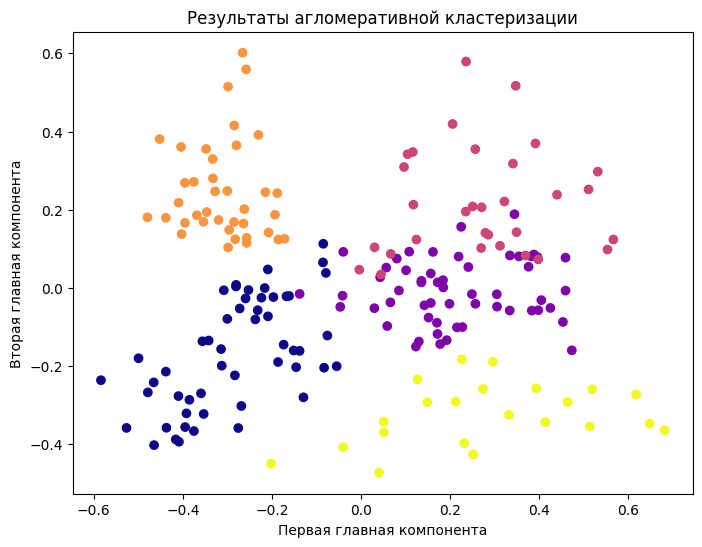

In [44]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data)
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_agglom,
cmap='plasma', marker='o')
plt.title('Результаты агломеративной кластеризации')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

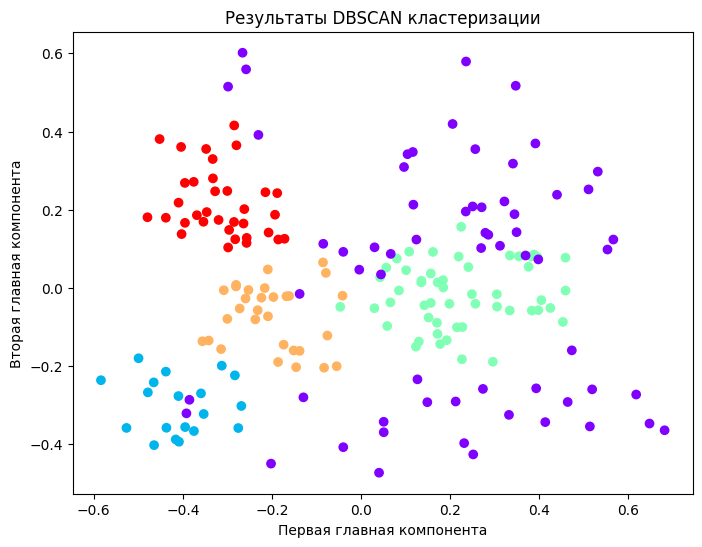

In [33]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data)
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_dbscan,
cmap='rainbow', marker='o')
plt.title('Результаты DBSCAN кластеризации')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

## 6 Сравнение результатов

In [24]:
print(f"K-means silhouette: {silhouette_score(data, labels_kmeans)}")
print(f"Hierarchical silhouette: {silhouette_score(data, labels_agglom)}")
print(f"DBSCAN silhouette: {silhouette_score(data, labels_dbscan)}")

K-means silhouette: 0.4128428517802903
Hierarchical silhouette: 0.40573947216363904
DBSCAN silhouette: 0.3013674455441658


In [ ]:
dbscan_1 = DBSCAN(eps=0.1, min_samples=5)
dbscan_1.fit(data)
dbscan_silhouette_1 = silhouette_score(data, dbscan_1.labels_)
dbscan_2 = DBSCAN(eps=0.2, min_samples=5)
dbscan_2.fit(data)
dbscan_silhouette_2 = silhouette_score(data, dbscan_2.labels_)
print(f"Silhouette for DBSCAN with eps=0.3: {dbscan_silhouette_1}")
print(f"Silhouette for DBSCAN with eps=0.7:{dbscan_silhouette_2}")

Silhouette for DBSCAN with eps=0.3: 0.04468442632665804
Silhouette for DBSCAN with eps=0.7:0.21142499818870225
